In [94]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, InputLayer, Reshape, Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, LeakyReLU, Conv2DTranspose
)
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
(x_train_org, y_train_org), (x_test_org, y_test_org) = cifar10.load_data()

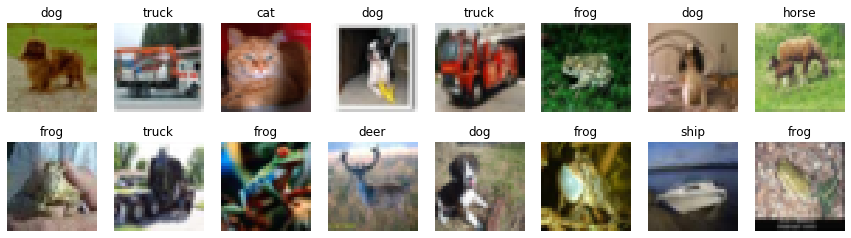

Train Samples:  (50000, 32, 32, 3) (50000, 1)
Test Samples:  (10000, 32, 32, 3) (10000, 1)


In [5]:
IMG_SHAPE = x_train_org[0].shape
NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer", 
                   "dog", "frog", "horse", "ship", "truck"]

# show random images from train
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train_org))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train_org[random_index, :])
        ax.set_title(cifar10_classes[y_train_org[random_index, 0]])
plt.show()
print("Train Samples: ", x_train_org.shape, y_train_org.shape)
print("Test Samples: ", x_test_org.shape, y_test_org.shape)

In [77]:
x_train_org = x_train_org.astype("float32")
x_train = x_train_org[:len(x_train_org)//2]
y_train = y_train_org[:len(y_train_org)//2]
x_val = x_train_org[3*len(x_train_org)//4:]
y_val = y_train_org[3*len(y_train_org)//4:]
x_test = x_test_org.astype("float32")
y_test = y_test_org

Text(0.5, 1.0, 'Sampled Data')

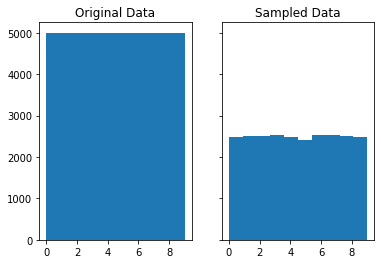

In [78]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].hist(y_train_org)
axes[0].set_title("Original Data")
axes[1].hist(y_train)
axes[1].set_title("Sampled Data")

I used (about) 50% of data from each classes.

In [79]:
print("Train Samples: ", x_train.shape, y_train.shape)
print("Test Samples: ", x_test.shape, y_test.shape)

Train Samples:  (25000, 32, 32, 3) (25000, 1)
Test Samples:  (10000, 32, 32, 3) (10000, 1)


I need to normalize inputs like this:

$$
x_\mathrm{norm} = \frac{x}{255} - 0.5
$$

I also need to convert class labels to one-hot encoded vectors. In this case, I used `keras.utils.to_categorical`.

In [80]:
# normalize inputs
# x_train_normed = (x_train - x_train.min()) / (x_train.max() - x_train.min()) 
x_train_normed = x_train / 255 - 0.5 
x_val_normed = x_val / 255 - 0.5
# x_test_normed = (x_test - x_test.min()) / (x_test.max() - x_test.min())
x_test_normed = x_test / 255 - 0.5 

# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_onehot = keras.utils.to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)

# Convolutional autoencoder
## Encoder
The encoder part is pretty standard, we stack convolutional and pooling layers and finish with a dense layer to get the representation of desirable size (code_size).

We recommend to use activation='elu' for all convolutional and dense layers.

We recommend to repeat (conv, pool) 4 times with kernel size (3, 3), padding='same' and the following numbers of output channels: 32, 64, 128, 256.

Remember to flatten (L.Flatten()) output before adding the last dense layer!

## Decoder
For decoder we will use so-called "transpose convolution".

Traditional convolutional layer takes a patch of an image and produces a number (patch -> number). In "transpose convolution" we want to take a number and produce a patch of an image (number -> patch). We need this layer to "undo" convolutions in encoder. We had a glimpse of it during week 3 (watch this video starting at 5:41).

In [15]:

def build_deep_autoencoder(img_shape, code_size):
    """PCA's deeper brother. See instructions above. Use `code_size` in layer definitions."""
    H,W,C = img_shape
    
    # encoder
    encoder = keras.models.Sequential()
    encoder.add(InputLayer(img_shape))
    ### YOUR CODE HERE: define encoder as per instructions above ###    
    # 
    encoder.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))
    #
    encoder.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))    
    #
    encoder.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))    
    #
    encoder.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))    
    #
    encoder.add(Flatten())
    encoder.add(Dense(code_size))
    encoder.add(Activation('elu'))
    # decoder
    decoder = keras.models.Sequential()
    decoder.add(InputLayer((code_size,)))
    decoder.add(Dense(2*2*256))
    decoder.add(Reshape((2, 2, 256)))
    decoder.add(Conv2DTranspose(filters=128, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))
    #
    decoder.add(Conv2DTranspose(filters=64, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))
    #
    decoder.add(Conv2DTranspose(filters=32, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))
    #
    decoder.add(Conv2DTranspose(filters=3, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))    
    return encoder, decoder

In [16]:

def build_shallow_autoencoder(img_shape, code_size):
    """PCA's deeper brother. See instructions above. Use `code_size` in layer definitions."""
    H,W,C = img_shape
    
    # encoder
    encoder = keras.models.Sequential()
    encoder.add(InputLayer(img_shape))
    ### YOUR CODE HERE: define encoder as per instructions above ###    
    # 
    encoder.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))
    #
    encoder.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same'))
    encoder.add(MaxPooling2D(pool_size=(2, 2)))
    encoder.add(Activation('elu'))    
    #
    encoder.add(Flatten())
    encoder.add(Dense(code_size))
    encoder.add(Activation('elu'))
    # decoder
    decoder = keras.models.Sequential()
    decoder.add(InputLayer((code_size,)))
    decoder.add(Dense(2*2*256))
    decoder.add(Reshape((2, 2, 256)))
    #
    decoder.add(Conv2DTranspose(filters=32, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))
    #
    decoder.add(Conv2DTranspose(filters=3, kernel_size=(3, 3), strides=2, activation='elu', padding='same'))    
    return encoder, decoder

In [17]:
get_dim = lambda layer: np.prod(layer.output_shape[1:])
for code_size in [1, 8, 32, 128, 512]:
    encoder, decoder = build_deep_autoencoder(IMG_SHAPE, code_size=code_size)
    print("Testing code size %i" % code_size)
    assert encoder.output_shape[1:] == (code_size,),"encoder must output a code of required size"
    assert decoder.output_shape[1:] == IMG_SHAPE,   "decoder must output an image of valid shape {} and {}".format(
        decoder.output_shape[1:], IMG_SHAPE
    )
    assert len(encoder.trainable_weights) >= 6,     "encoder must contain at least 3 layers"
    assert len(decoder.trainable_weights) >= 6,     "decoder must contain at least 3 layers"

    for layer in encoder.layers + decoder.layers:
        assert get_dim(layer) >= code_size, "Encoder layer %s is smaller than bottleneck (%i units) %i"%(layer.name,get_dim(layer), code_size)

print("All tests passed!")

Testing code size 1
Testing code size 8
Testing code size 32
Testing code size 128
Testing code size 512
All tests passed!


In [27]:
from tensorflow import keras
import tqdm
from collections import defaultdict
import numpy as np


class TqdmProgressCallback(keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']

    def on_epoch_begin(self, epoch, logs=None):
        print('Epoch %d/%d' % (epoch + 1, self.epochs))
        if "steps" in self.params:
            self.use_steps = True
            self.target = self.params['steps']
        else:
            self.use_steps = False
            self.target = self.params['samples']
        self.prog_bar = tqdm.notebook.tqdm(total=self.target)
        self.log_values_by_metric = defaultdict(list)

    def _set_prog_bar_desc(self, logs):
        for k in self.params['metrics']:
            if k in logs:
                self.log_values_by_metric[k].append(logs[k])
        desc = "; ".join("{0}: {1:.3f}".format(k, np.mean(values)) for k, values in self.log_values_by_metric.items())
        self.prog_bar.set_description(desc)

    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        if self.use_steps:
            self.prog_bar.update(1)
        else:
            batch_size = logs.get('size', 0)
            self.prog_bar.update(batch_size)
        self._set_prog_bar_desc(logs)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self._set_prog_bar_desc(logs)
        self.prog_bar.update(1)  # workaround to show description
        self.prog_bar.close()

In [108]:
next(datagen.flow(x_train_normed)).shape

(32, 32, 32, 3)

In [109]:
x_train_normed[0].shape 

(32, 32, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


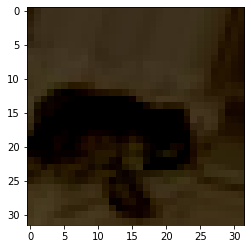

In [110]:
plt.imshow(next(datagen.flow(x_train_normed)))

In [111]:
encoder, decoder = build_deep_autoencoder(IMG_SHAPE, code_size=64) # Default is 32

In [112]:
inp = Input(IMG_SHAPE)
code = encoder(inp)
reconstruction = decoder(code)
TRAIN = False
if TRAIN:
    autoencoder = keras.models.Model(inputs=inp, outputs=reconstruction)
    autoencoder.compile(optimizer="adamax", loss='mse')
    autoencoder.fit(x=x_train_normed, y=x_train_normed, epochs=100,
                    validation_data=(x_val_normed, x_val_normed),
                    callbacks=[TqdmProgressCallback()],
                    verbose=0)
    encoder.save_weights("../models/encoder.h5")
    decoder.save_weights("../models/decoder.h5")
else:
    encoder, decoder = build_deep_autoencoder(IMG_SHAPE, code_size=64)
    encoder.load_weights("../models/encoder.h5")
    decoder.load_weights("../models/decoder.h5")    
    autoencoder = keras.models.Model(inputs=inp, outputs=reconstruction)
    autoencoder.compile(optimizer="adamax", loss='mse')

In [82]:
def show_image(x):
#     plt.imshow(x)
    plt.imshow(np.clip(x + 0.5, 0, 1))

In [83]:
def visualize(img,encoder,decoder):
    """Draws original, encoded and decoded images"""
    code = encoder.predict(img[None])[0]  # img[None] is the same as img[np.newaxis, :]
    reco = decoder.predict(code[None])[0]

    plt.subplot(1,3,1)
    plt.title("Original")
    show_image(img)

    plt.subplot(1,3,2)
    plt.title("Code")
    plt.imshow(code.reshape([code.shape[-1]//2,-1]))
    plt.subplot(1,3,3)
    plt.title("Reconstructed")
    show_image(reco)
    plt.show()


Convolutional autoencoder MSE: 0.00825784865617752


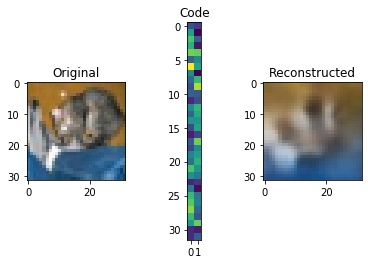

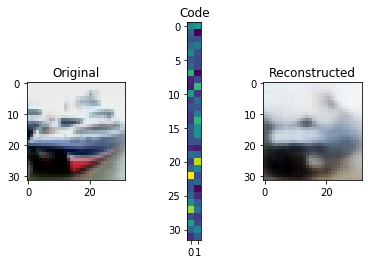

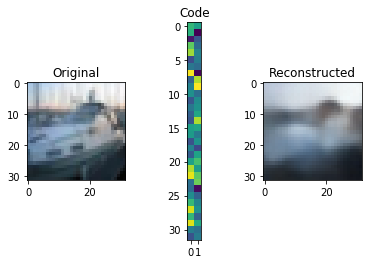

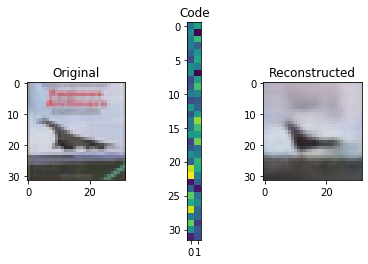

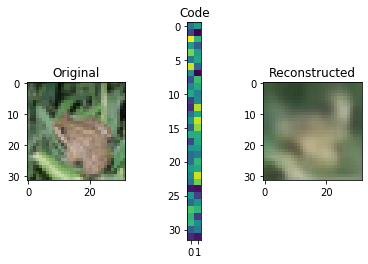

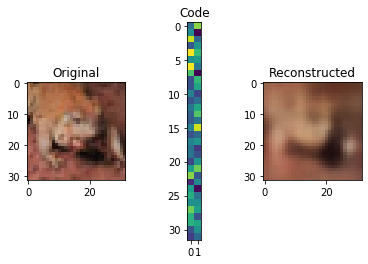

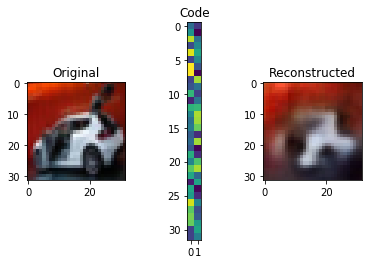

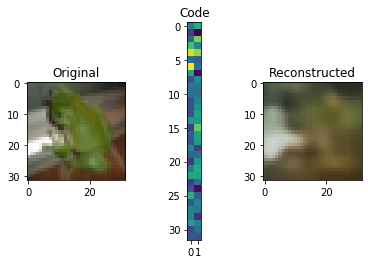

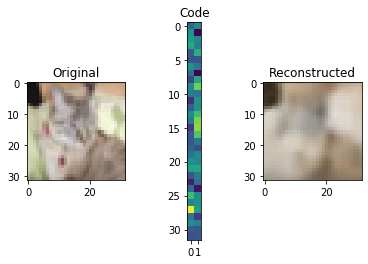

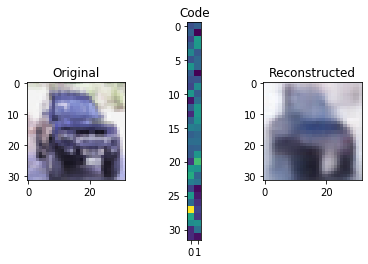

In [84]:
reconstruction_mse = autoencoder.evaluate(x_test_normed, x_test_normed, verbose=0)
print("Convolutional autoencoder MSE:", reconstruction_mse)
for i in range(10):
    img = x_test_normed[i]
    visualize(img,encoder,decoder)

## Construct classifier

In [85]:
encoder.summary()

Model: "sequential_50"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_76 (Conv2D)           (None, 32, 32, 32)        896       
_________________________________________________________________
max_pooling2d_76 (MaxPooling (None, 16, 16, 32)        0         
_________________________________________________________________
activation_95 (Activation)   (None, 16, 16, 32)        0         
_________________________________________________________________
conv2d_77 (Conv2D)           (None, 16, 16, 64)        18496     
_________________________________________________________________
max_pooling2d_77 (MaxPooling (None, 8, 8, 64)          0         
_________________________________________________________________
activation_96 (Activation)   (None, 8, 8, 64)          0         
_________________________________________________________________
conv2d_78 (Conv2D)           (None, 8, 8, 128)       

It turns out

In [ ]:
datagen = ImageDataGenerator(rotation_range = 20, horizontal_flip = True, height_shift_range = 0.2,\
                            width_shift_range = 0.2,zoom_range = 0.2, channel_shift_range = 0.2
                            )
datagen.fit(x_train_normed)
train_generator = datagen.flow(x_train_normed, y_train_onehot, batch_size=BATCH_SIZE)
validation_generator = datagen.flow(x_val_normed, y_val_onehot, batch_size=BATCH_SIZE)

In [ ]:
INIT_LR = 5e-2  # initial learning rate
BATCH_SIZE = 32
EPOCHES = 100
encoder, decoder = build_deep_autoencoder(IMG_SHAPE, code_size=64)
encoder.load_weights("../models/encoder.h5")
classifier = keras.models.Sequential()
for layer in encoder.layers[:-1]:
    layer.trainable = True
    classifier.add(layer)
# Fine tuning only the last layers
for layer in classifier.layers[:-1]:
    layer.traineble = False
classifier.add(
    Dense(
        NUM_CLASSES, activation="softmax"
    )
)
classifier.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adamax(),
    metrics=["accuracy"]  # report accuracy during training
)
# scheduler of learning rate (decay with epochs)
def lr_scheduler(epoch):
    return INIT_LR * 0.9 ** epoch

# callback for printing of actual learning rate used by optimizer
class LrHistory(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs={}):
        print("Learning rate:", keras.backend.get_value(model.optimizer.lr))
        
TRAIN = True
if TRAIN:
    classifier.fit(train_generator,
                   epochs=EPOCHES,
                   validation_data=validation_generator,
                   callbacks=[
                       keras.callbacks.EarlyStopping(
                           monitor="val_loss",
                           patience=5,
                           min_delta=0,
                           mode="min"
                       ),
                       TqdmProgressCallback()
                   ],
                   shuffle=True,
                   verbose=0)
    classifier.save_weights("../models/classifier.h5")
else:
    classifier.build(input_shape=(32, 32, 3))
    classifier.load_weights("../models/classifier.h5")

  ...
    to  
  ['...']
Epoch 1/100


In [ ]:
classifier.summary()

In [ ]:
classifier.evaluate(x_test_normed, y_test_onehot, verbose=0)

In [ ]:
y_pred_test = classifier.predict_proba(x_test_normed)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test, y_pred_test_classes))

In [ ]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test_org[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test[random_index, 0]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()